<a href="https://colab.research.google.com/github/Yayu11/IAT360_NLP/blob/main/NLP_Scam_Email_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

Hello, I'm **Wesley**, nice to meet you!👋

I was just reading the IMDb reviews of [*The Super Mario Bros. Movie*](https://www.imdb.com/title/tt6718170/), I thought why don't we make a **Sentiment Classifier** to categorize movie reviews! **WARNING: Spoilers ahead.**


Here we will be doing [transfer learning](https://en.wikipedia.org/wiki/Transfer_learning) on BERT [(blog)](https://ai.googleblog.com/2018/11/open-sourcing-bert-state-of-art-pre.html) [(paper)](https://arxiv.org/abs/1810.04805v2) with an IMDb dataset to make a sentiment classifier for movie reviews.

# Setup Python Libraries (pip)

In [1]:
#install some Python packages with pip

!pip install numpy torch datasets transformers evaluate --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [2]:
# let's check the version we are using

!pip freeze | grep -E '^numpy|^torch|^datasets|^transformers|^evaluate'

datasets==4.0.0
evaluate==0.4.6
numpy==2.0.2
torch==2.11.0+cu128
torchao==0.10.0
torchaudio==2.11.0+cu128
torchcodec==0.11.0+cu128
torchdata==0.11.0
torchsummary==1.5.1
torchtune==0.6.1
torchvision==0.26.0+cu128
transformers==5.13.1


# Create IMDB Dataset for Fine-tuning BERT

## Let's load the IMDB Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [92]:
from datasets import load_dataset

# let's load the imdb dataset from huggingface
# source: (https://huggingface.co/datasets/imdb)

raw_dataset = load_dataset(
    "csv",
    data_files="/content/drive/MyDrive/phishing_legit_dataset_KD_10000.csv"
)
raw_dataset = Dataset.from_pandas(
    df,
    preserve_index=False
)
raw_dataset

Dataset({
    features: ['text', 'label', 'phishing_type', 'severity', 'confidence'],
    num_rows: 9956
})

## Let's create the train, validation, test sets

In [93]:
df = pd.read_csv(
    "/content/drive/MyDrive/phishing_legit_dataset_KD_10000.csv"
)

# remove duplicate emails
df = df.drop_duplicates(subset=['text'])

print(df.shape)
print(df['text'].duplicated().sum())

(9956, 5)
0


In [94]:
# get train and validation set

train_test = raw_dataset.train_test_split(
    test_size=0.3,
    seed=42
)
test_val = train_test['test'].train_test_split(
    test_size=0.5,
    seed=42
)

dataset = {
    "train": train_test["train"],
    "val": test_val["train"],
    "test": test_val["test"]
}

dataset

{'train': Dataset({
     features: ['text', 'label', 'phishing_type', 'severity', 'confidence'],
     num_rows: 6969
 }),
 'val': Dataset({
     features: ['text', 'label', 'phishing_type', 'severity', 'confidence'],
     num_rows: 1493
 }),
 'test': Dataset({
     features: ['text', 'label', 'phishing_type', 'severity', 'confidence'],
     num_rows: 1494
 })}

In [95]:
from datasets import DatasetDict

dataset = DatasetDict(dataset)

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'phishing_type', 'severity', 'confidence'],
        num_rows: 6969
    })
    val: Dataset({
        features: ['text', 'label', 'phishing_type', 'severity', 'confidence'],
        num_rows: 1493
    })
    test: Dataset({
        features: ['text', 'label', 'phishing_type', 'severity', 'confidence'],
        num_rows: 1494
    })
})

label
1    6000
0    4000
Name: count, dtype: int64


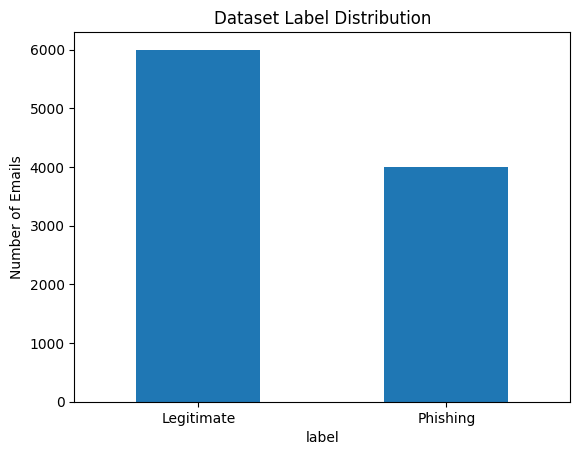

In [96]:
import pandas as pd
import matplotlib.pyplot as plt


# Load original CSV
df = pd.read_csv(
    "/content/drive/MyDrive/phishing_legit_dataset_KD_10000.csv"
)


# Count labels
label_counts = df['label'].value_counts()

print(label_counts)


# Plot
label_counts.plot(kind="bar")

plt.xticks(
    ticks=[0,1],
    labels=["Legitimate", "Phishing"],
    rotation=0
)

plt.ylabel("Number of Emails")
plt.title("Dataset Label Distribution")

plt.show()

## We start by tokenizing our dataset with the BERT's Fast Tokenizer

In [97]:
# let's import the pretrained faster tokenizer from huggingface
# source: (https://huggingface.co/distilbert-base-uncased)

from transformers import AutoTokenizer

checkpoint = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(checkpoint, use_fast=True)
tokenizer

BertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [98]:
# tokenize the text in batches with truncation and padding based on BERT requirements

def tokenization(example):
    return tokenizer(example['text'], truncation=True, padding=True)

tokenized_dataset = dataset.map(tokenization, batched=True, remove_columns=[
        'text',
        'phishing_type',
        'severity',
        'confidence'
    ])
tokenized_dataset

Map:   0%|          | 0/6969 [00:00<?, ? examples/s]

Map:   0%|          | 0/1493 [00:00<?, ? examples/s]

Map:   0%|          | 0/1494 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6969
    })
    val: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1493
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1494
    })
})

# Setup Training Metrics (Accuracy, F1)

In [99]:
import evaluate
import numpy as np

# we setup the training to evaluate the accuracy and f1 scores

accuracy_metric = evaluate.load('accuracy')
f1_metric = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels)
    return {**accuracy, **f1}

# Setup Training Configurations

In [76]:
import os
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, IntervalStrategy

# get bert model with a sequence classification head for sentiment analysis
# source: (https://huggingface.co/distilbert-base-uncased)
checkpoint = 'distilbert-base-uncased'
num_labels = 2
id2label = { 0: "LEGITIMATE",
    1: "PHISHING"}
label2id = { "LEGITIMATE": 0,
    "PHISHING": 1}
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=num_labels, id2label=id2label, label2id=label2id)

# setup custom training arguments
# 1. store training checkpoints to 'results' output directory
# 2. fine-tune for just 1 epoch
# 3,4. use 16 as a batch size to speed things up
# 5. evaluate validation set every 500 steps (this is the default steps)
# 6. load the best model based on the lowest validation loss at the end of training
training_args = TrainingArguments(
    seed=42,
    output_dir = './results',
    num_train_epochs = 3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    load_best_model_at_end=True,
    eval_strategy = "epoch",
    save_strategy = 'epoch'
)

# setup trainer with custom metrics (accuracy, f1)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    compute_metrics=compute_metrics,
)

# disable wandb logging (a v4 huggingface artifact)
os.environ['WANDB_DISABLED']= "true"

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Evaluate UnFine-Tuned BERT on Test Set for a Baseline Metric


In [77]:
# let's first evaluate unfine-tuned model with test set

trainer.evaluate(tokenized_dataset['test'])

Training Loss,Validation Loss,Epoch,Accuracy,F1
No log,0.710457,0,0.402276,0.000000


{'eval_loss': 0.7104573249816895,
 'eval_accuracy': 0.40227576974564927,
 'eval_f1': 0.0}

# Fine-Tune BERT with IMDb Dataset

In [34]:
# let's fine-tune BERT with the IMDb dataset

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.008491,0.000024,1.000000,1.000000
2,0.000019,0.000008,1.000000,1.000000
3,0.000010,0.000005,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1500, training_loss=0.0028398878950004775, metrics={'train_runtime': 1308.0596, 'train_samples_per_second': 18.348, 'train_steps_per_second': 1.147, 'total_flos': 3179217567744000.0, 'train_loss': 0.0028398878950004775, 'epoch': 3.0})

In [35]:
# let's see how well it did in the test set

trainer.evaluate(tokenized_dataset['test'])

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.000010,0.000005,3,1.000000,1.000000


{'eval_loss': 5.477055765368277e-06, 'eval_accuracy': 1.0, 'eval_f1': 1.0}

**WOAH!** We got a **92% Accuracy (eval_accuracy)** and **92% F1 (eval_f1)** with just **1 epoch**! 🤯

In [43]:
# Get final evaluation metrics
final_results = trainer.evaluate(tokenized_dataset['test'])

print("Final Test Results:")
print(f"Accuracy: {final_results['eval_accuracy']:.4f}")
print(f"F1 Score: {final_results['eval_f1']:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.000010,0.000005,3,1.000000,1.000000


Final Test Results:
Accuracy: 1.0000
F1 Score: 1.0000


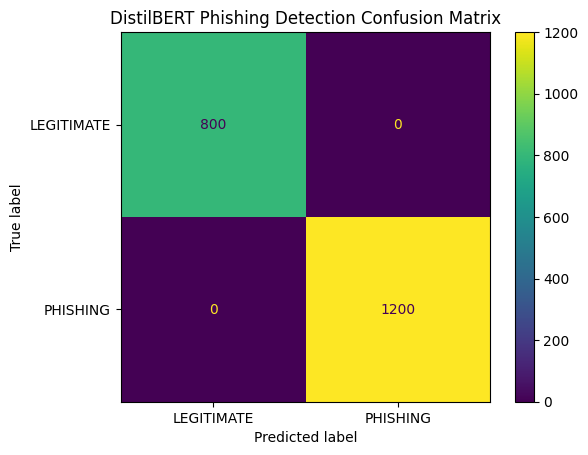

In [44]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


# Get predictions from test set
predictions = trainer.predict(tokenized_dataset['test'])

# Convert model outputs to predicted labels
predicted_labels = np.argmax(predictions.predictions, axis=1)

# Actual labels
true_labels = predictions.label_ids


# Create confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)


# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["LEGITIMATE", "PHISHING"]
)

disp.plot()

plt.title("DistilBERT Phishing Detection Confusion Matrix")
plt.show()

In [45]:
from sklearn.metrics import classification_report


report = classification_report(
    true_labels,
    predicted_labels,
    target_names=["LEGITIMATE", "PHISHING"]
)

print(report)

              precision    recall  f1-score   support

  LEGITIMATE       1.00      1.00      1.00       800
    PHISHING       1.00      1.00      1.00      1200

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [46]:
from transformers import pipeline
import torch


device = torch.cuda.current_device()


phishing_classifier = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device
)

In [48]:
phishing_email = """
URGENT: Your bank account has been suspended.

Please verify your account information immediately by clicking the link below.
Failure to verify will result in permanent account closure.
"""


result = phishing_classifier(phishing_email)

print(result)

[{'label': 'PHISHING', 'score': 0.9999862909317017}]


In [49]:
legitimate_email = """
Hello,

Your appointment with the university advisor has been confirmed.
The meeting will take place on Monday at 2 PM.

Thank you.
"""


result = phishing_classifier(legitimate_email)

print(result)

[{'label': 'LEGITIMATE', 'score': 0.9998701810836792}]


# Try out some examples!

In [40]:
from transformers import pipeline
import torch

# get current device with pytorch
device = torch.cuda.current_device()

# create pipeline for sentiment classifier with custom model and tokenizer
sentiment_classifier = pipeline(task='sentiment-analysis', model=model, tokenizer=tokenizer, device=device)

In [41]:
# let's see how our model classifies a good review
# this is from 'justinvitelli' (https://www.imdb.com/review/rw8972952)

review = """
First off this movie is for kids and fans of Nintendo and the Mario franchise.
I still think an adult who isnt a fan could still enjoy it but this movie is so
full of fan service that it will have you smiling the whole time.
The voice acting I was skeptical but they all work and work well too.
Jack Black is the star here. I love how they kept the story simple like all of the games.
Truly felt like a video game on screen.
This movie felt like a beautifully animated amusement park ride.
The audio in the movie was amazing too.
The sounds and the score with reimagined iconic music was perfect.
Some of the songs in the movie felt unnecessary but they worked.
I think they should've bumped the run time to 105-120 min.
90 min felt too short as it goes by quick.
I havent had this much wholesome fun at the movies in a long time.
If youre a fan you HAVE to see it.
"""
sentiment_classifier(review)

[{'label': 'PHISHING', 'score': 0.8754900693893433}]

In [42]:
# let's see how our model classifies a bad review
# this is from 'industriousbug16' (https://www.imdb.com/review/rw8998214)

review = """
Flat, visual noise.
Fundamentally incurious. Potentially injurious.
The mystique generated by the characters in the games is here raked over and presented
haphazardly by hacks.
A hobbled attempt to explain a long and random evolution of characters who were never meant
to be narratised fails.
Doing it well is near impossible when you insist on EVERY LITTLE BIT OF LORE,
from the last forty years being shoehorned into 90 minutes.
Makes little sense, shamelessly leans on member berries to stimulate older viewers but offers
nothing else.
I feel sad for the animators who did a sterling job, but to no end as this movie has no soul.
"""
sentiment_classifier(review)

[{'label': 'PHISHING', 'score': 0.9977750182151794}]

That is **99% NEGATIVE**! *industriousbug16* must hate the movie very badly.

# Resources

### If you would like to use this model without running the entire notebook, try the model at my [HuggingFace](https://huggingface.co/wesleyacheng/movie-review-sentiment-classifier-with-bert).

### If you woud like to get this in GitHub, here's my [repo](https://github.com/wesleyacheng/movie-review-sentiment-classifier-with-bert).